In [2]:
import requests
import pandas as pd

url = "https://data.moenv.gov.tw/api/v2/aqx_p_488?format=json&offset=0&limit=5&api_key=c7ede899-2baa-40d8-985e-0c8c020314c6"

response = requests.get(url)

data = response.json()

df = pd.DataFrame(data)

df.head()

,sitename,county,aqi,pollutant,status,so2,so2_avg,co,co_8hr,o3,...,no2,nox,no,windspeed,winddirec,datacreationdate,longitude,latitude,siteid,unit
0,屏東（枋山）,屏東縣,61,臭氧八小時,普通,0,0,0.19,0.1,58,...,2,2.4,0.1,2.5,327.0,2026-03-19 18:00,120.651472,22.260899,313,
1,新北（樹林）,新北市,41,,良好,1,0,0.41,0.3,45,...,16,21,4.1,0.9,129.0,2026-03-19 18:00,121.38352778,24.94902778,311,
2,屏東（琉球）,屏東縣,48,,良好,0.2,0,0.21,0.2,53,...,2,3.2,0.8,2.8,321.0,2026-03-19 18:00,120.37722,22.35222,204,
3,南投（鹿谷）,南投縣,86,細懸浮微粒,普通,1.7,1,0.22,0.2,60,...,5,5.5,0.4,0.4,244.0,2026-03-19 18:00,120.7944772,23.71867609,203,
4,林森,臺南市,63,懸浮微粒,普通,1.3,1,0.57,0.3,48,...,13,17.1,3.3,1.5,85.0,2026-03-19 18:00,120.22216042,22.98522502,140,


In [3]:
numeric_cols = [
    "aqi", "so2", "so2_avg", "co", "co_8hr",
    "o3", "o3_8hr", "pm10", "pm10_avg",
    "pm2.5", "pm2.5_avg",
    "no2", "nox", "no",
    "windspeed", "winddirec",
    "longitude", "latitude"
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df["datacreationdate"] = pd.to_datetime(df["datacreationdate"])

core_cols = [
    "sitename", "county",
    "aqi", "pm2.5", "pm10", "o3",
    "windspeed", "winddirec",
    "datacreationdate",
    "longitude", "latitude"
]

df_clean = df[core_cols].copy()

df_clean.head()

,sitename,county,aqi,pm2.5,pm10,o3,windspeed,winddirec,datacreationdate,longitude,latitude
0,屏東（枋山）,屏東縣,61,14,33,58,2.5,327.0,2026-03-19 18:00:00,120.651472,22.260899
1,新北（樹林）,新北市,41,8,7,45,0.9,129.0,2026-03-19 18:00:00,121.383528,24.949028
2,屏東（琉球）,屏東縣,48,10,33,53,2.8,321.0,2026-03-19 18:00:00,120.377220,22.352220
3,南投（鹿谷）,南投縣,86,25,39,60,0.4,244.0,2026-03-19 18:00:00,120.794477,23.718676
4,林森,臺南市,63,20,47,48,1.5,85.0,2026-03-19 18:00:00,120.222160,22.985225


In [4]:
df.dtypes

sitename                    object
county                      object
aqi                          int64
pollutant                   object
status                      object
so2                        float64
so2_avg                      int64
co                         float64
co_8hr                     float64
o3                           int64
o3_8hr                       int64
pm10                         int64
pm10_avg                     int64
pm2.5                        int64
pm2.5_avg                  float64
no2                          int64
nox                        float64
no                         float64
windspeed                  float64
winddirec                  float64
datacreationdate    datetime64[ns]
longitude                  float64
latitude                   float64
siteid                      object
unit                        object
dtype: object

In [5]:
aqi_by_county = (
    df_clean.groupby("county")["aqi"]
    .mean()
    .sort_values(ascending=False)
)

aqi_by_county.head(10)

county
南投縣    86.0
臺南市    63.0
屏東縣    54.5
新北市    41.0
Name: aqi, dtype: float64

In [8]:
df_clean["hour"] = df_clean["datacreationdate"].dt.hour

aqi_by_hour = (
    df_clean.groupby("hour")["aqi"]
    .mean()
    .sort_values(ascending=False)
)

aqi_by_hour_sorted = aqi_by_hour.sort_index()

aqi_by_hour_sorted

hour
18    59.8
Name: aqi, dtype: float64

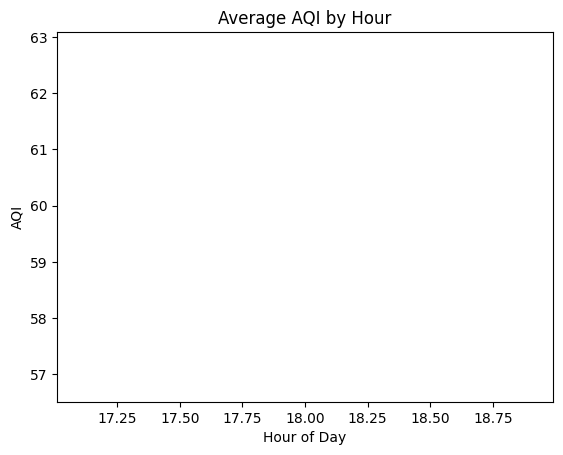

In [9]:
import matplotlib.pyplot as plt

aqi_by_hour_sorted.plot()
plt.title("Average AQI by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("AQI")
plt.show()